# 赛益宁销量分析


## 1. 环境准备

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi', 'FangSong']
plt.rcParams['axes.unicode_minus'] = False

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

## 2. 数据加载

In [ ]:
# 数据路径
data_path = r'E:\全国省份预测模型\data\赛益宁\20251204'

# 定义一个函数来尝试不同编码读取CSV
def read_csv_with_encoding(file_path):
    """尝试使用不同编码读取CSV文件"""
    encodings = ['gbk', 'utf-8', 'utf-8-sig', 'gb2312', 'gb18030']
    
    for encoding in encodings:
        try:
            df = pd.read_csv(file_path, encoding=encoding)
            file_name = file_path.split('\\')[-1]  # 先提取文件名
            print(f"成功读取 {file_name} (编码: {encoding})")
            return df
        except UnicodeDecodeError:
            continue
        except Exception as e:
            print(f"读取 {file_path} 时发生错误: {e}")
            continue
    
    raise ValueError(f"无法读取文件 {file_path}，尝试了所有常见编码")

# 读取Soliqua.csv数据（包含所有规格）
print("正在加载数据...")
df_all = read_csv_with_encoding(f'{data_path}\\Soliqua.csv')

print(f"\n总数据: {df_all.shape[0]} 行, {df_all.shape[1]} 列")

# 检查并处理规格字段
if 'prodmdmcode' in df_all.columns:
    # 从产品编码中提取规格标识
    df_all['规格_原始'] = df_all['prodmdmcode'].astype(str)
    
    # 根据产品编码判断规格（170或171）
    # 假设产品编码中包含规格信息，需要根据实际数据调整判断逻辑
    def extract_spec(code):
        code_str = str(code)
        if '170' in code_str:
            return '170'
        elif '171' in code_str:
            return '171'
        else:
            # 如果无法从编码判断，可以根据其他字段或默认处理
            return 'unknown'
    
    df_all['规格'] = df_all['prodmdmcode'].apply(extract_spec)
    
    print(f"\n规格分布:\n{df_all['规格'].value_counts()}")
    
    # 如果有unknown规格，给出警告
    if 'unknown' in df_all['规格'].values:
        print(f"警告: 发现无法识别规格的记录 {len(df_all[df_all['规格']=='unknown'])} 条")
else:
    print("警告: 未找到产品编码字段 'prodmdmcode'")
    # 尝试其他可能的规格字段
    if 'spec' in df_all.columns:
        df_all['规格'] = df_all['spec'].astype(str)
    elif 'specification' in df_all.columns:
        df_all['规格'] = df_all['specification'].astype(str)
    else:
        print("错误: 无法确定规格字段")

# 分别提取170和171规格数据（保持原有变量名）
df_170 = df_all[df_all['规格'] == '170'].copy()
df_171 = df_all[df_all['规格'] == '171'].copy()

print(f"\n规格170数据: {df_170.shape[0]} 行, {df_170.shape[1]} 列")
print(f"规格171数据: {df_171.shape[0]} 行, {df_171.shape[1]} 列")

# 重命名字段：将 cnvrtdqty 改为 qty（如果存在）
if 'cnvrtdqty' in df_all.columns:
    df_all = df_all.rename(columns={'cnvrtdqty': 'qty'})

# 转换日期格式
if 'bizym' in df_all.columns:
    df_all['bizym'] = df_all['bizym'].astype(str)
    df_all['年月'] = pd.to_datetime(df_all['bizym'], format='%Y%m', errors='coerce')
    df_all['年'] = df_all['年月'].dt.year
    df_all['月'] = df_all['年月'].dt.month

# 确保销量字段为数值型（保留正负值）
if 'qty' in df_all.columns:
    df_all['qty'] = pd.to_numeric(df_all['qty'], errors='coerce')

# 同步更新df_170和df_171的字段处理
for df_spec in [df_170, df_171]:
    if 'cnvrtdqty' in df_spec.columns and 'qty' not in df_spec.columns:
        df_spec.rename(columns={'cnvrtdqty': 'qty'}, inplace=True)
    
    if 'bizym' in df_spec.columns:
        df_spec['bizym'] = df_spec['bizym'].astype(str)
        df_spec['年月'] = pd.to_datetime(df_spec['bizym'], format='%Y%m', errors='coerce')
        df_spec['年'] = df_spec['年月'].dt.year
        df_spec['月'] = df_spec['年月'].dt.month
    
    if 'qty' in df_spec.columns:
        df_spec['qty'] = pd.to_numeric(df_spec['qty'], errors='coerce')

print(f"\n合并后总数据量: {df_all.shape[0]} 行")
if '规格' in df_all.columns:
    print(f"各规格数据量:\n{df_all['规格'].value_counts()}")

# 显示前几行数据以验证
print("\n数据示例：")
if all(col in df_all.columns for col in ['bizym', 'transdate', 'tophncode', 'tophnname', 'tomdmprovince', 'tomdmcity', 'tohospitallevel', 'qty', '规格']):
    print(df_all[['bizym', 'transdate', 'tophncode', 'tophnname', 'tomdmprovince', 
                  'tomdmcity', 'tohospitallevel', 'qty', '规格']].head(10))
else:
    # 显示实际存在的字段
    available_cols = [col for col in ['bizym', 'transdate', 'tophncode', 'tophnname', 'tomdmprovince', 'tomdmcity', 'tohospitallevel', 'qty', '规格'] if col in df_all.columns]
    if available_cols:
        print(df_all[available_cols].head(10))
    else:
        print(df_all.head(10))

正在加载数据...
成功读取 Soliqua.csv (编码: gbk)

总数据: 91194 行, 18 列

规格分布:
规格
170    69176
171    22018
Name: count, dtype: int64

规格170数据: 69176 行, 20 列
规格171数据: 22018 行, 20 列

合并后总数据量: 91194 行
各规格数据量:
规格
170    69176
171    22018
Name: count, dtype: int64

数据示例：
    bizym   transdate    tophncode             tophnname tomdmprovince tomdmcity tohospitallevel  qty   规格
0  202510  2025-10-21  PHN01659552        饶阳县王同岳镇卫生院京堂分院           河北省       衡水市             未评级    2  170
1  202510  2025-10-15  PHN02915596        荔湾区广钢新城社区卫生服务站           广东省       广州市             未评级    2  170
2  202510  2025-10-27  PHN01784912       长垣市蒲西街道社区卫生服务中心           河南省       新乡市             未评级    1  170
3  202510  2025-10-04  PHN03016392         新橙门诊部（广州）有限公司           广东省       广州市             未评级    1  170
4  202510  2025-10-22  PHN01817998          宁城县三座店镇中心卫生院        内蒙古自治区       赤峰市              一级    2  170
5  202510  2025-10-17  PHN01668924             任丘市长丰镇卫生院           河北省       沧州市              一级    2  1

In [4]:
# 字段标准化处理
# 确保关键字段存在
required_fields = ['bizym', 'qty', 'tomdmprovince', 'tomdmcity', 'tophncode', 'tophnname']
missing_fields = [f for f in required_fields if f not in df_all.columns]

if missing_fields:
    print(f"警告: 缺少字段 {missing_fields}")
    print(f"当前可用字段: {df_all.columns.tolist()}")
else:
    print("所有必需字段都存在")

# 转换日期格式（如果前面没有处理）
if 'bizym' in df_all.columns and '年月' not in df_all.columns:
    df_all['bizym'] = df_all['bizym'].astype(str)
    df_all['年月'] = pd.to_datetime(df_all['bizym'], format='%Y%m', errors='coerce')
    df_all['年'] = df_all['年月'].dt.year
    df_all['月'] = df_all['年月'].dt.month

if '年月' in df_all.columns:
    print(f"\n数据时间范围: {df_all['年月'].min()} 至 {df_all['年月'].max()}")

# 确保销量字段为数值型
if 'qty' in df_all.columns:
    df_all['qty'] = pd.to_numeric(df_all['qty'], errors='coerce')
    print(f"\n销量字段统计:")
    print(df_all['qty'].describe())
    
    # 按规格显示销量统计
    if '规格' in df_all.columns:
        print(f"\n各规格销量统计:")
        for spec in df_all['规格'].unique():
            if spec != 'unknown':
                print(f"\n规格 {spec}:")
                print(df_all[df_all['规格']==spec]['qty'].describe())

所有必需字段都存在

数据时间范围: 2023-05-01 00:00:00 至 2025-10-01 00:00:00

销量字段统计:
count    91194.000000
mean        23.262243
std         56.999619
min      -2760.000000
25%          2.000000
50%          6.000000
75%         20.000000
max       2760.000000
Name: qty, dtype: float64

各规格销量统计:

规格 170:
count    69176.000000
mean        21.666228
std         48.137963
min      -1200.000000
25%          2.000000
50%          6.000000
75%         20.000000
max       1440.000000
Name: qty, dtype: float64

规格 171:
count    22018.000000
mean        28.276592
std         78.378782
min      -2760.000000
25%          2.000000
50%         10.000000
75%         30.000000
max       2760.000000
Name: qty, dtype: float64


# 整体路径

## 170


【170规格销量预测：整体6个月预测方案(v5优化版 + YoY合理性分析)】

【第一步：数据准备】
✓ 月度数据准备完成，共22个月
  时间范围: 2024-01 ~ 2025-10

【历史同月环比增长率统计】
         mean     median        std  count
月份                                        
1   49.961373  49.961373        NaN      1
2  -19.123583 -19.123583   1.326157      2
3   71.411684  71.411684  15.967394      2
4   -6.682496  -6.682496   8.695559      2
5   29.175185  29.175185  15.140995      2
6    8.834117   8.834117   6.295099      2
7   -8.796001  -8.796001  17.691558      2
8   23.296784  23.296784   4.521746      2
9   27.575267  27.575267  14.807889      2
10 -36.759545 -36.759545  15.857785      2
11  43.304033  43.304033        NaN      1
12 -12.959835 -12.959835        NaN      1

【第二步：构建整体6个月预测样本(v5版本修正)】

【第三步：生成训练样本】
✓ 生成11个训练样本
  特征维度: (11, 125)
  特征数量: 125个(v5: 删除YoY+混淆特征, 增加月份编码)

【第四步：智能缺失值填充】

训练数据缺失值统计(前10个):
  - ly_销量_均值: 1个缺失值
  - ly_销量_标准差: 1个缺失值
  - ly_环比_均值: 2个缺失值
  - ly_环比_中位数: 2个缺失值
  - ly_整体斜率: 2个缺失值
  - ly_R方: 2个缺失值
  - ly_M1_销量: 6个缺失值
  - ly_M

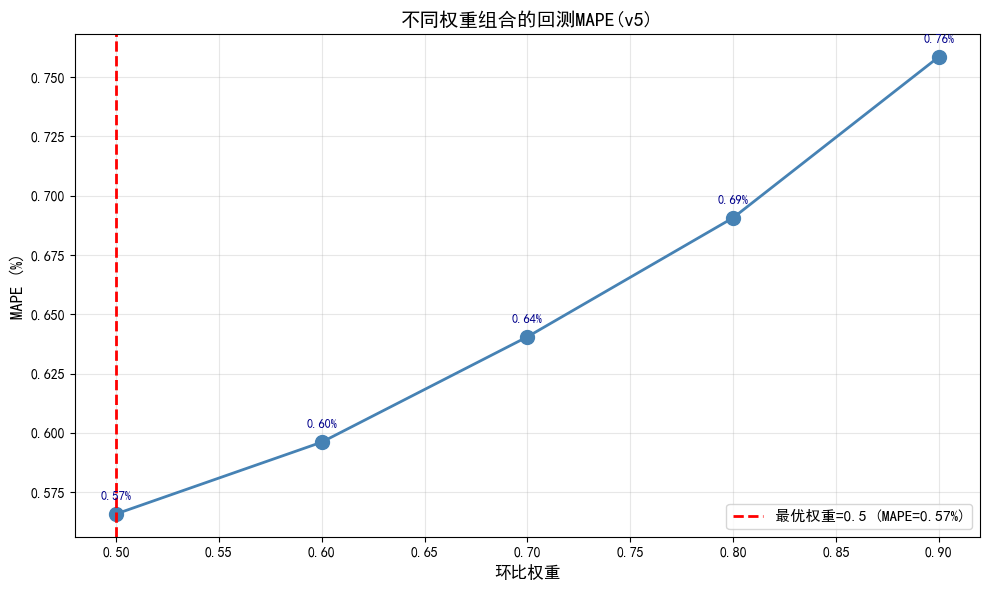


✅ 权重优化图已保存


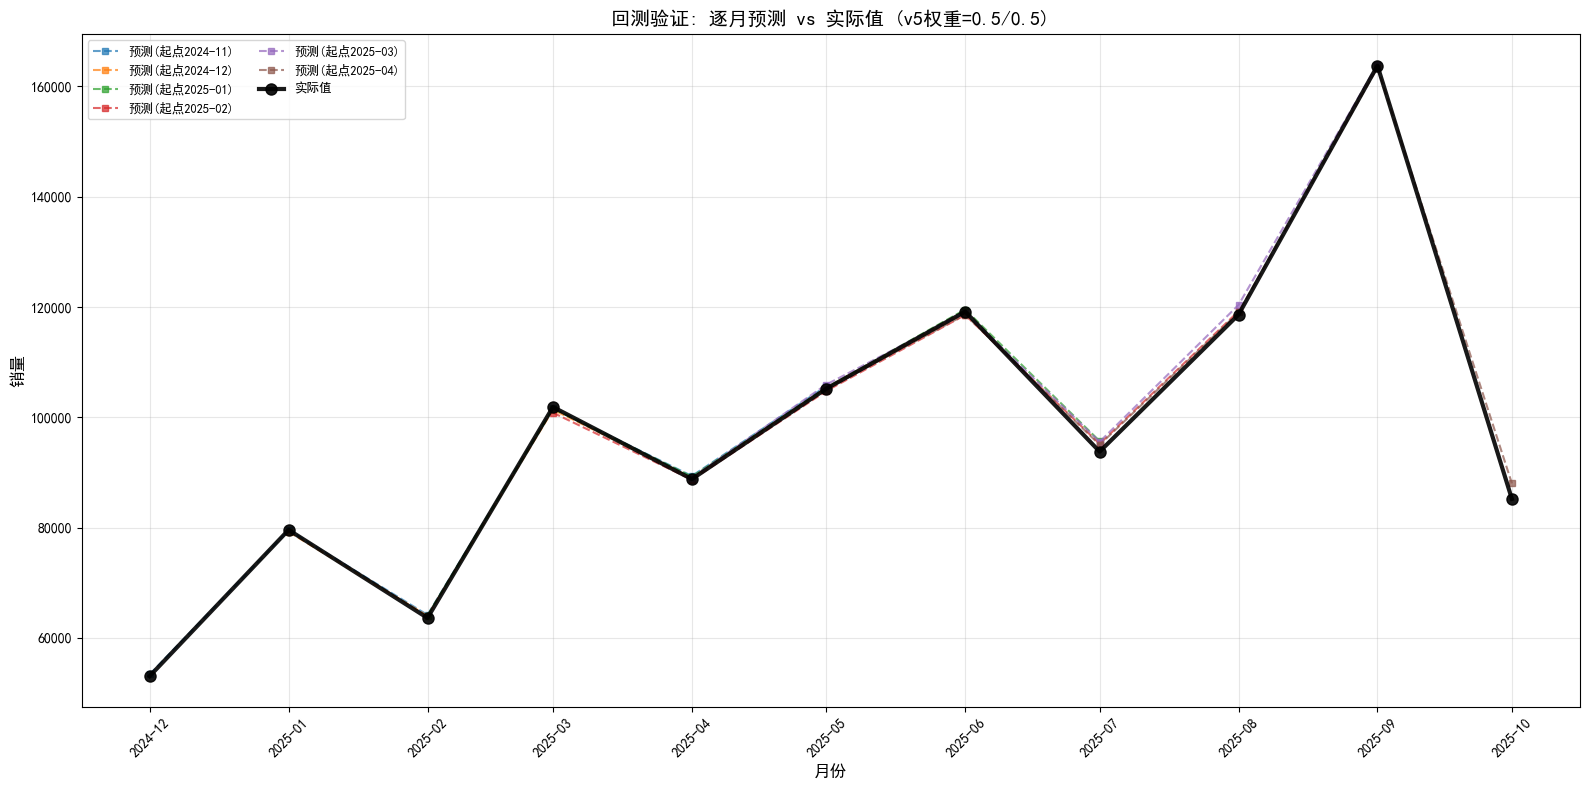

✅ 回测可视化已保存

【第七步：使用最优权重预测未来6个月】

✅ 使用最优权重: 环比0.5 + 绝对值0.5
✅ v5版本: 删除混淆特征 + 增加月份one-hot编码

【预测结果】
月份                     绝对值预测            环比预测          最优权重预测        预测环比%
2025-11               134456          135969          135212        58.70%
2025-12               130289          109855          120072       -11.20%
2026-01               146671          143980          145325        21.03%
2026-02               136503          117545          127024       -12.59%
2026-03               188036          177541          182789        43.90%
2026-04               150733          130715          140724       -23.01%
6个月总计                 886688          815605          851146

【第九步：完整可视化（历史+预测+YoY+线性拟合）】


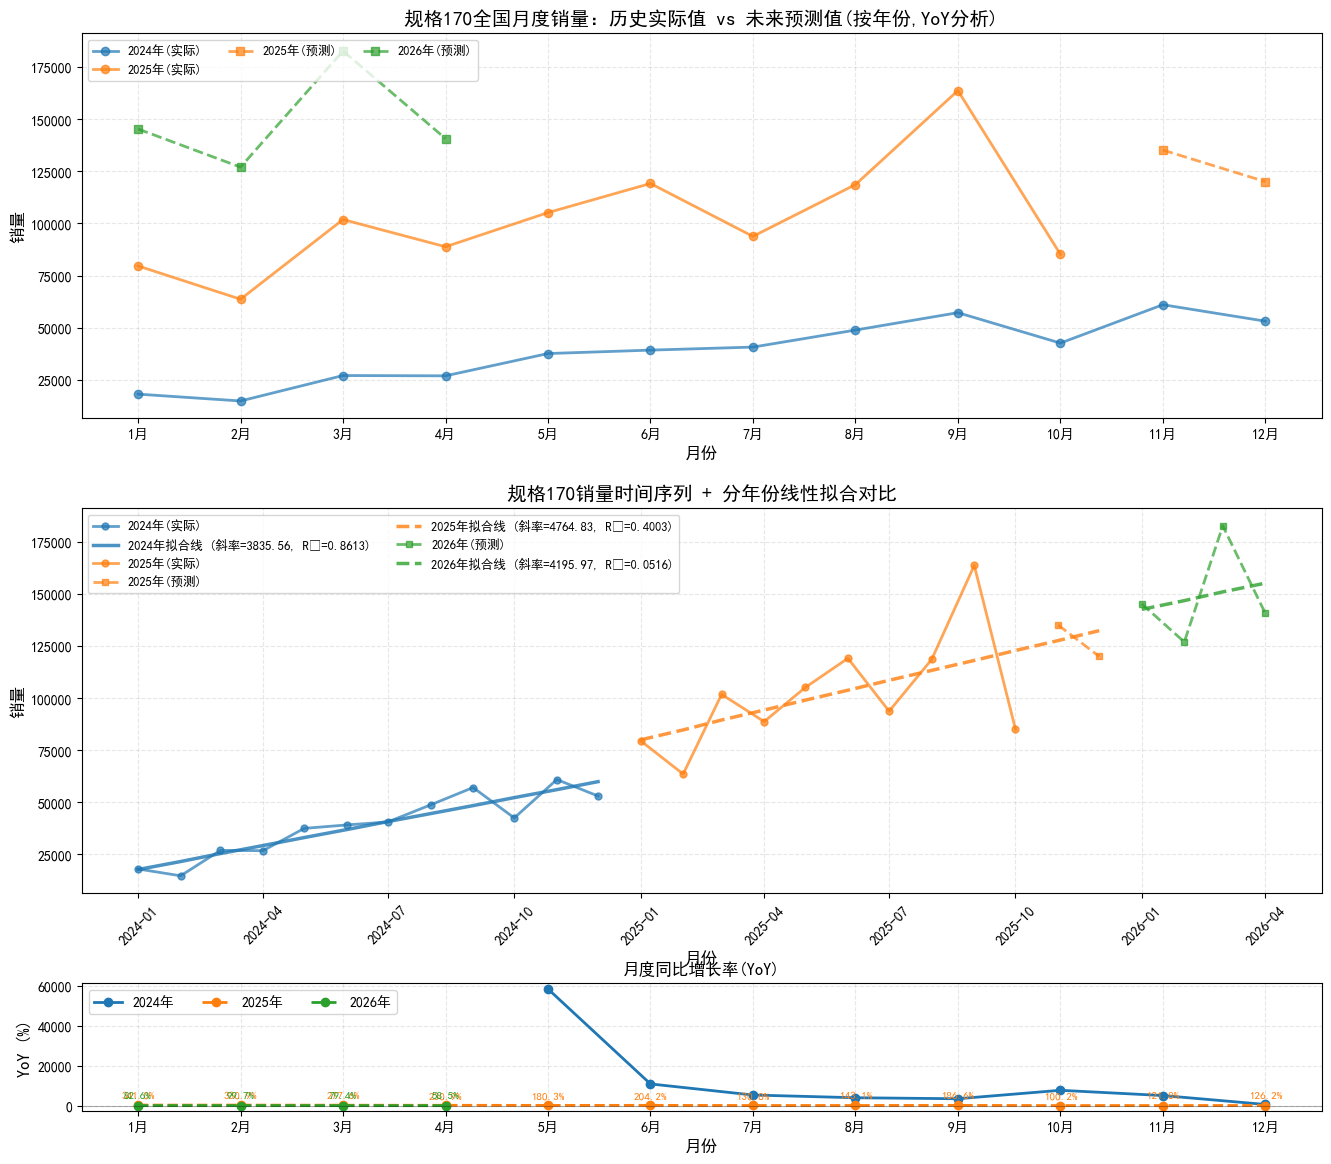


✅ 可视化已保存: 规格170_v5预测_YoY分析_线性拟合对比.png

【第十步：v5版本特征重要性分析】

环比模型预测2026-02的特征权重(TOP20):
                            特征        权重
76   future_M4_hist_mom_median  1.495855
75     future_M4_hist_mom_mean  1.495855
72                    ly_M4_环比  1.412060
4                    ly_环比_中位数  1.369381
93     future_M5_hist_mom_mean -1.347138
94   future_M5_hist_mom_median -1.347138
67            future_M3_is_sep -1.288250
105           future_M5_is_nov -1.288250
86            future_M4_is_oct -1.288250
48            future_M2_is_aug -1.288250
29            future_M1_is_jul -1.288250
124           future_M6_is_dec -1.288250
90                    ly_M5_环比 -1.269562
121           future_M6_is_sep -1.246900
102           future_M5_is_aug -1.246900
83            future_M4_is_jul -1.246900
64            future_M3_is_jun -1.246900
26            future_M1_is_apr -1.246900
45            future_M2_is_may -1.246900
68            future_M3_is_oct  1.233161

2月相关特征权重:
                            特征        权重
7

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

print("\n" + "="*100)
print("【170规格销量预测：整体6个月预测方案(v5优化版 + YoY合理性分析)】")
print("="*100)

# ============================================================
# 第一步：准备数据
# ============================================================

print("\n" + "="*90)
print("【第一步：数据准备】")
print("="*90)

df_170 = df_all[df_all['规格'] == '170'].copy()
df_170['年月'] = pd.to_datetime(df_170['年月'])

# 按月汇总销量
df_monthly = (
    df_170.groupby('年月', as_index=False)
    .agg(销量=('qty', 'sum'))
    .sort_values('年月')
    .reset_index(drop=True)
)

# 筛选2024-01开始的数据
df_monthly = df_monthly[df_monthly['年月'] >= pd.Timestamp('2024-01-01')].copy()

# 计算环比增长率
df_monthly['环比增长率'] = df_monthly['销量'].pct_change() * 100
df_monthly['月份'] = df_monthly['年月'].dt.month

print(f"✓ 月度数据准备完成，共{len(df_monthly)}个月")
print(f"  时间范围: {df_monthly['年月'].min().strftime('%Y-%m')} ~ {df_monthly['年月'].max().strftime('%Y-%m')}")

# 统计历史同月环比模式
print(f"\n【历史同月环比增长率统计】")
print("="*90)
month_mom_stats = df_monthly.groupby('月份')['环比增长率'].agg(['mean', 'median', 'std', 'count'])
print(month_mom_stats)

# ============================================================
# 第二步：构建整体6个月预测样本
# ============================================================

print("\n" + "="*90)
print("【第二步：构建整体6个月预测样本(v5版本修正)】")
print("="*90)

def create_holistic_samples_v5(df, target_date):
    """
    为指定预测起点创建整体6个月预测样本
    """
    
    # 预测目标: target_date往后6个月
    future_months = pd.date_range(target_date + pd.DateOffset(months=1), periods=6, freq='MS')
    
    df_historical = df[df['年月'] <= target_date].copy()
    
    # 特征1: 去年同期6个月的销量
    same_period_last_year = pd.date_range(target_date - pd.DateOffset(months=11), periods=6, freq='MS')
    
    sales_last_year = []
    mom_last_year = []
    
    for i in range(6):
        month_ly = same_period_last_year[i]
        
        sale_ly = df_historical[df_historical['年月'] == month_ly]['销量'].values
        mom_ly = df_historical[df_historical['年月'] == month_ly]['环比增长率'].values
        
        if len(sale_ly) > 0:
            sales_last_year.append(sale_ly[0])
            if len(mom_ly) > 0:
                mom_last_year.append(mom_ly[0])
            else:
                mom_last_year.append(np.nan)
        else:
            sales_last_year.append(np.nan)
            mom_last_year.append(np.nan)
    
    # 特征2: 前6个月的销量和环比
    recent_6_months = pd.date_range(target_date - pd.DateOffset(months=5), periods=6, freq='MS')
    sales_recent = []
    mom_recent = []
    
    for i in range(6):
        month_curr = recent_6_months[i]
        
        sale_curr = df_historical[df_historical['年月'] == month_curr]['销量'].values
        mom_curr = df_historical[df_historical['年月'] == month_curr]['环比增长率'].values
        
        if len(sale_curr) > 0:
            sales_recent.append(sale_curr[0])
            if len(mom_curr) > 0:
                mom_recent.append(mom_curr[0])
            else:
                mom_recent.append(np.nan)
        else:
            sales_recent.append(np.nan)
            mom_recent.append(np.nan)
    
    # 特征3: 历史同月环比
    future_month_nums = [m.month for m in future_months]
    hist_mom_mean = []
    hist_mom_median = []
    
    for month_num in future_month_nums:
        hist_data = df_historical[df_historical['月份'] == month_num]['环比增长率'].dropna()
        if len(hist_data) > 0:
            hist_mom_mean.append(hist_data.mean())
            hist_mom_median.append(hist_data.median())
        else:
            hist_mom_mean.append(np.nan)
            hist_mom_median.append(np.nan)
    
    # 特征4: 去年同期6个月的整体拟合线斜率
    if not all(np.isnan(sales_last_year)):
        valid_idx = [i for i, x in enumerate(sales_last_year) if not np.isnan(x)]
        if len(valid_idx) >= 2:
            x_ly = np.array(valid_idx)
            y_ly = np.array([sales_last_year[i] for i in valid_idx])
            slope_ly, _, r_ly, _, _ = stats.linregress(x_ly, y_ly)
        else:
            slope_ly, r_ly = np.nan, np.nan
    else:
        slope_ly, r_ly = np.nan, np.nan
    
    # 特征5: 前6个月的整体拟合线斜率
    if not all(np.isnan(sales_recent)):
        valid_idx = [i for i, x in enumerate(sales_recent) if not np.isnan(x)]
        if len(valid_idx) >= 2:
            x_rec = np.array(valid_idx)
            y_rec = np.array([sales_recent[i] for i in valid_idx])
            slope_rec, _, r_rec, _, _ = stats.linregress(x_rec, y_rec)
        else:
            slope_rec, r_rec = np.nan, np.nan
    else:
        slope_rec, r_rec = np.nan, np.nan
    
    # 特征6: 预测起点的销量（M当月）
    base_sale = df_historical[df_historical['年月'] == target_date]['销量'].values
    base_sale = base_sale[0] if len(base_sale) > 0 else np.nan
    
    # 组装特征字典
    features = {
        # 去年同期6个月特征
        'ly_销量_均值': np.nanmean(sales_last_year),
        'ly_销量_总和': np.nansum(sales_last_year),
        'ly_销量_标准差': np.nanstd(sales_last_year),
        'ly_环比_均值': np.nanmean(mom_last_year),
        'ly_环比_中位数': np.nanmedian(mom_last_year),
        'ly_整体斜率': slope_ly,
        'ly_R方': r_ly,
        
        # 前6个月特征
        'rec_销量_均值': np.nanmean(sales_recent),
        'rec_销量_总和': np.nansum(sales_recent),
        'rec_销量_标准差': np.nanstd(sales_recent),
        'rec_环比_均值': np.nanmean(mom_recent),
        'rec_环比_中位数': np.nanmedian(mom_recent),
        'rec_整体斜率': slope_rec,
        'rec_R方': r_rec,
                
        # 预测起点销量
        'base_销量': base_sale,
        
        # 季节性特征
        '未来_起始月': future_month_nums[0],
        '未来_结束月': future_month_nums[-1],
    }
    
    # 逐月细粒度特征
    for i in range(6):
        features[f'ly_M{i+1}_销量'] = sales_last_year[i]
        features[f'ly_M{i+1}_环比'] = mom_last_year[i]
        features[f'rec_M{i+1}_销量'] = sales_recent[i]
        features[f'rec_M{i+1}_环比'] = mom_recent[i]
        features[f'future_M{i+1}_hist_mom_mean'] = hist_mom_mean[i]
        features[f'future_M{i+1}_hist_mom_median'] = hist_mom_median[i]
        
        #月份one-hot编码
        month_num = future_month_nums[i]
        features[f'future_M{i+1}_is_jan'] = 1 if month_num == 1 else 0
        features[f'future_M{i+1}_is_feb'] = 1 if month_num == 2 else 0
        features[f'future_M{i+1}_is_mar'] = 1 if month_num == 3 else 0
        features[f'future_M{i+1}_is_apr'] = 1 if month_num == 4 else 0
        features[f'future_M{i+1}_is_may'] = 1 if month_num == 5 else 0
        features[f'future_M{i+1}_is_jun'] = 1 if month_num == 6 else 0
        features[f'future_M{i+1}_is_jul'] = 1 if month_num == 7 else 0
        features[f'future_M{i+1}_is_aug'] = 1 if month_num == 8 else 0
        features[f'future_M{i+1}_is_sep'] = 1 if month_num == 9 else 0
        features[f'future_M{i+1}_is_oct'] = 1 if month_num == 10 else 0
        features[f'future_M{i+1}_is_nov'] = 1 if month_num == 11 else 0
        features[f'future_M{i+1}_is_dec'] = 1 if month_num == 12 else 0
    
    # 提取目标(销量绝对值)
    targets_abs = []
    for m in future_months:
        sale = df[df['年月'] == m]['销量'].values
        targets_abs.append(sale[0] if len(sale) > 0 else np.nan)
    
    # 计算目标(环比增长率)
    targets_mom = []
    prev_sale = base_sale
    for i, sale in enumerate(targets_abs):
        if not np.isnan(sale) and not np.isnan(prev_sale) and prev_sale > 0:
            mom = (sale - prev_sale) / prev_sale * 100
            targets_mom.append(mom)
            prev_sale = sale
        else:
            targets_mom.append(np.nan)
    
    return features, targets_abs, targets_mom, future_months


# ============================================================
# 第三步：生成训练样本
# ============================================================

print("\n" + "="*90)
print("【第三步：生成训练样本】")
print("="*90)

train_start = pd.Timestamp('2024-06-01')
train_end = pd.Timestamp('2025-04-01')

train_dates = pd.date_range(train_start, train_end, freq='MS')

train_samples = []
train_targets_abs = []
train_targets_mom = []

for date in train_dates:
    features, targets_abs, targets_mom, _ = create_holistic_samples_v5(df_monthly, date)
    
    # 检查是否有完整目标
    if not any(np.isnan(targets_abs)) and not any(np.isnan(targets_mom)):
        train_samples.append(features)
        train_targets_abs.append(targets_abs)
        train_targets_mom.append(targets_mom)

print(f"✓ 生成{len(train_samples)}个训练样本")

# 转为DataFrame
train_X = pd.DataFrame(train_samples)
train_y_abs = np.array(train_targets_abs)
train_y_mom = np.array(train_targets_mom)

print(f"  特征维度: {train_X.shape}")
print(f"  特征数量: {train_X.shape[1]}个(v5: 删除YoY+混淆特征, 增加月份编码)")

# ============================================================
# 第四步：智能缺失值填充
# ============================================================

print("\n" + "="*90)
print("【第四步：智能缺失值填充】")
print("="*90)

# 检查缺失值情况
nan_counts = train_X.isna().sum()
print(f"\n训练数据缺失值统计(前10个):")
if nan_counts.sum() > 0:
    for col, count in nan_counts[nan_counts > 0].head(10).items():
        print(f"  - {col}: {count}个缺失值")

# 计算环比统计量
mom_cols = [col for col in train_X.columns if '环比' in col]
mom_valid_values = []
for col in mom_cols:
    mom_valid_values.extend(train_X[col].dropna().values)

if len(mom_valid_values) > 0:
    mom_median = np.median(mom_valid_values)
    print(f"\n历史环比统计: 中位数={mom_median:.2f}%")
else:
    mom_median = 0

# 分列填充
train_X_filled = train_X.copy()

for col in train_X_filled.columns:
    if train_X_filled[col].isna().all():
        train_X_filled[col] = 0
    elif '环比' in col:
        if train_X_filled[col].notna().any():
            col_median = train_X_filled[col].median()
            n_missing = train_X_filled[col].isna().sum()
            if n_missing > 0:
                train_X_filled[col] = train_X_filled[col].fillna(col_median)
        else:
            train_X_filled[col] = 0
    elif '斜率' in col or 'R方' in col:
        n_missing = train_X_filled[col].isna().sum()
        if n_missing > 0:
            train_X_filled[col] = train_X_filled[col].fillna(0)
    else:
        if train_X_filled[col].notna().any():
            col_mean = train_X_filled[col].mean()
            n_missing = train_X_filled[col].isna().sum()
            if n_missing > 0:
                train_X_filled[col] = train_X_filled[col].fillna(col_mean)
        else:
            train_X_filled[col] = 0

if train_X_filled.isna().sum().sum() == 0:
    print(f"\n✓ 缺失值填充完成，无NaN残留")

# 标准化
scaler_X = StandardScaler()
train_X_scaled = scaler_X.fit_transform(train_X_filled)

print(f"✓ 特征标准化完成")

# ============================================================
# 第五步：训练混合模型
# ============================================================

print("\n" + "="*90)
print("【第五步：训练混合模型】")
print("="*90)

# 方案1: 预测绝对值(Ridge)
models_abs = []
for i in range(6):
    model = Ridge(alpha=5.0, random_state=42)
    model.fit(train_X_scaled, train_y_abs[:, i])
    models_abs.append(model)

# 方案2: 预测环比增长率(Ridge)
models_mom = []
for i in range(6):
    model = Ridge(alpha=5.0, random_state=42)
    model.fit(train_X_scaled, train_y_mom[:, i])
    models_mom.append(model)

print(f"\n✓ 6个绝对值Ridge模型训练完成(alpha=5.0)")
print(f"✓ 6个环比增长率Ridge模型训练完成(alpha=5.0)")

# ============================================================
# 第六步：选择最优权重
# ============================================================

print("\n" + "="*90)
print("【第六步：选择最优权重")
print("="*90)

max_date = df_monthly['年月'].max()
backtest_end = max_date - pd.DateOffset(months=6)  #
backtest_start = pd.Timestamp('2024-11-01')

# 检查回测窗口是否有效
if backtest_end < backtest_start:
    print(f"⚠️ 数据不足,调整回测起点")
    backtest_start = backtest_end - pd.DateOffset(months=2)

backtest_dates = pd.date_range(backtest_start, backtest_end, freq='MS')

# 定义权重候选
weight_candidates = [0.5, 0.6, 0.7, 0.8, 0.9]

print(f"\n回测配置:")
print(f"  数据最大月份: {max_date.strftime('%Y-%m')}")
print(f"  回测窗口: {backtest_dates[0].strftime('%Y-%m')} ~ {backtest_dates[-1].strftime('%Y-%m')} ({len(backtest_dates)}个月)")
print(f"  权重候选: {weight_candidates}")

results = []
backtest_details = []

for w_mom in weight_candidates:
    w_abs = 1 - w_mom
    
    all_errors = []
    
    for bt_date in backtest_dates:
        features_bt, targets_abs_bt, targets_mom_bt, future_months_bt = create_holistic_samples_v5(df_monthly, bt_date)
        
        # 检查未来6个月数据是否完整
        if any(np.isnan(targets_abs_bt)):
            print(f"  ⚠️ 跳过{bt_date.strftime('%Y-%m')}: 未来6个月数据不完整")
            continue
        
        # 转为DataFrame并填充
        pred_X_bt = pd.DataFrame([features_bt])
        pred_X_bt_filled = pred_X_bt.copy()
        
        for col in pred_X_bt_filled.columns:
            if col in train_X_filled.columns:
                if '环比' in col:
                    col_median = train_X_filled[col].median()
                    pred_X_bt_filled[col] = pred_X_bt_filled[col].fillna(col_median)
                elif train_X_filled[col].mean() == 0 and train_X_filled[col].std() == 0:
                    pred_X_bt_filled[col] = pred_X_bt_filled[col].fillna(0)
                else:
                    pred_X_bt_filled[col] = pred_X_bt_filled[col].fillna(train_X_filled[col].mean())
            else:
                pred_X_bt_filled[col] = pred_X_bt_filled[col].fillna(0)
        
        pred_X_bt_scaled = scaler_X.transform(pred_X_bt_filled)
        
        # 预测绝对值
        pred_abs_bt = np.array([model.predict(pred_X_bt_scaled)[0] for model in models_abs])
        
        # 预测环比
        pred_mom_rates_bt = np.array([model.predict(pred_X_bt_scaled)[0] for model in models_mom])
        
        base_sale_bt = df_monthly[df_monthly['年月'] == bt_date]['销量'].values[0]
        pred_from_mom_bt = []
        current_sale = base_sale_bt
        for mom_rate in pred_mom_rates_bt:
            next_sale = current_sale * (1 + mom_rate / 100)
            pred_from_mom_bt.append(next_sale)
            current_sale = next_sale
        pred_from_mom_bt = np.array(pred_from_mom_bt)
        
        # 混合预测
        pred_ensemble_bt = w_mom * pred_from_mom_bt + w_abs * pred_abs_bt
        
        # 计算MAPE
        targets_abs_bt_array = np.array(targets_abs_bt)
        errors = np.abs((pred_ensemble_bt - targets_abs_bt_array) / targets_abs_bt_array)
        all_errors.extend(errors)
        
        # 保存回测详情
        if w_mom == 0.7:
            for i in range(6):
                backtest_details.append({
                    '回测起点': bt_date,
                    '预测月份': future_months_bt[i],
                    '预测值': pred_ensemble_bt[i],
                    '实际值': targets_abs_bt[i],
                    'MAPE': errors[i] * 100
                })
    
    # 计算平均MAPE
    if len(all_errors) > 0:
        avg_mape = np.mean(all_errors) * 100
        results.append({
            'w_mom': w_mom,
            'w_abs': w_abs,
            'MAPE': avg_mape,
            'n_samples': len(all_errors) // 6
        })
        
        print(f"  权重 环比{w_mom:.1f}+绝对值{w_abs:.1f}: MAPE={avg_mape:.2f}% (样本数={len(all_errors)//6})")

# 选择最优权重
if len(results) > 0:
    results_df = pd.DataFrame(results)
    best_row = results_df.loc[results_df['MAPE'].idxmin()]
    
    print(f"\n" + "="*90)
    print(f"【最优权重组合】")
    print(f"="*90)
    print(f"  环比权重: {best_row['w_mom']:.1f}")
    print(f"  绝对值权重: {best_row['w_abs']:.1f}")
    print(f"  回测MAPE: {best_row['MAPE']:.2f}%")
    print(f"  回测样本数: {int(best_row['n_samples'])}个")
    
    optimal_w_mom = best_row['w_mom']
    optimal_w_abs = best_row['w_abs']
    
    # 可视化1: 权重-MAPE曲线
    fig_weight, ax_weight = plt.subplots(1, 1, figsize=(10, 6))
    ax_weight.plot(results_df['w_mom'], results_df['MAPE'], marker='o', linewidth=2, markersize=10, color='steelblue')
    ax_weight.axvline(best_row['w_mom'], color='red', linestyle='--', linewidth=2, 
                     label=f"最优权重={best_row['w_mom']:.1f} (MAPE={best_row['MAPE']:.2f}%)")
    ax_weight.set_xlabel('环比权重', fontsize=12, fontweight='bold')
    ax_weight.set_ylabel('MAPE (%)', fontsize=12, fontweight='bold')
    ax_weight.set_title('不同权重组合的回测MAPE(v5)', fontsize=14, fontweight='bold')
    ax_weight.legend(fontsize=11)
    ax_weight.grid(True, alpha=0.3)
    
    for _, row in results_df.iterrows():
        ax_weight.annotate(f"{row['MAPE']:.2f}%", 
                          xy=(row['w_mom'], row['MAPE']),
                          xytext=(0, 10), textcoords='offset points',
                          ha='center', fontsize=9, color='darkblue')
    
    plt.tight_layout()
    plt.savefig('170规格_权重优化_回测MAPE_v5_含YoY分析.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ 权重优化图已保存")
    
    # 可视化2: 回测逐月预测vs实际
    if len(backtest_details) > 0:
        backtest_df = pd.DataFrame(backtest_details)
        
        fig_bt, ax_bt = plt.subplots(1, 1, figsize=(16, 8))
        
        for bt_start in backtest_df['回测起点'].unique():
            bt_group = backtest_df[backtest_df['回测起点'] == bt_start].sort_values('预测月份')
            
            ax_bt.plot(bt_group['预测月份'], bt_group['预测值'], 
                      marker='s', linestyle='--', linewidth=1.5, markersize=5,
                      label=f"预测(起点{bt_start.strftime('%Y-%m')})", alpha=0.7)
        
        actual_months = backtest_df['预测月份'].unique()
        actual_sales = []
        for m in sorted(actual_months):
            sale = df_monthly[df_monthly['年月'] == m]['销量'].values
            actual_sales.append(sale[0] if len(sale) > 0 else np.nan)
        
        ax_bt.plot(sorted(actual_months), actual_sales, 
                  marker='o', linewidth=3, markersize=8, color='black',
                  label='实际值', alpha=0.9, zorder=10)
        
        ax_bt.set_xlabel('月份', fontsize=12, fontweight='bold')
        ax_bt.set_ylabel('销量', fontsize=12, fontweight='bold')
        ax_bt.set_title(f'回测验证: 逐月预测 vs 实际值 (v5权重={optimal_w_mom:.1f}/{optimal_w_abs:.1f})', 
                       fontsize=14, fontweight='bold')
        ax_bt.legend(fontsize=9, loc='upper left', ncol=2)
        ax_bt.grid(True, alpha=0.3)
        ax_bt.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.savefig('权重选择.png', dpi=150, bbox_inches='tight')
        plt.show()
        
    
else:
    print(f"\n⚠️ 选择失败,使用默认权重 0.7/0.3")
    optimal_w_mom = 0.7
    optimal_w_abs = 0.3

# ============================================================
# 第七步：使用最优权重预测未来6个月
# ============================================================

print("\n" + "="*90)
print("【第七步：使用最优权重预测未来6个月】")
print("="*90)

pred_date = pd.Timestamp('2025-10-01')
features_pred, _, _, future_months = create_holistic_samples_v5(df_monthly, pred_date)

# 转为DataFrame并填充
pred_X = pd.DataFrame([features_pred])
pred_X_filled = pred_X.copy()

for col in pred_X_filled.columns:
    if col in train_X_filled.columns:
        if '环比' in col:
            col_median = train_X_filled[col].median()
            pred_X_filled[col] = pred_X_filled[col].fillna(col_median)
        elif train_X_filled[col].mean() == 0 and train_X_filled[col].std() == 0:
            pred_X_filled[col] = pred_X_filled[col].fillna(0)
        else:
            pred_X_filled[col] = pred_X_filled[col].fillna(train_X_filled[col].mean())
    else:
        pred_X_filled[col] = pred_X_filled[col].fillna(0)

pred_X_scaled = scaler_X.transform(pred_X_filled)

# 预测
pred_abs = np.array([model.predict(pred_X_scaled)[0] for model in models_abs])

pred_mom_rates = np.array([model.predict(pred_X_scaled)[0] for model in models_mom])

base_sale = df_monthly[df_monthly['年月'] == pred_date]['销量'].values[0]
pred_from_mom = []
current_sale = base_sale
for mom_rate in pred_mom_rates:
    next_sale = current_sale * (1 + mom_rate / 100)
    pred_from_mom.append(next_sale)
    current_sale = next_sale
pred_from_mom = np.array(pred_from_mom)

# 混合策略
pred_ensemble = optimal_w_mom * pred_from_mom + optimal_w_abs * pred_abs

print(f"\n✅ 使用最优权重: 环比{optimal_w_mom:.1f} + 绝对值{optimal_w_abs:.1f}")

# 输出结果
print("\n【预测结果】")
print("="*110)
print(f"{'月份':<12} {'绝对值预测':>15} {'环比预测':>15} {'最优权重预测':>15} {'预测环比%':>12}")
print("="*110)

for i, month in enumerate(future_months):
    if i == 0:
        mom_pct = (pred_ensemble[i] - base_sale) / base_sale * 100
    else:
        mom_pct = (pred_ensemble[i] - pred_ensemble[i-1]) / pred_ensemble[i-1] * 100
    
    print(f"{month.strftime('%Y-%m'):<12} {pred_abs[i]:>15.0f} {pred_from_mom[i]:>15.0f} {pred_ensemble[i]:>15.0f} {mom_pct:>12.2f}%")

print("="*110)
print(f"{'6个月总计':<12} {pred_abs.sum():>15.0f} {pred_from_mom.sum():>15.0f} {pred_ensemble.sum():>15.0f}")

# ============================================================
# 第八步：完整可视化（历史+预测+YoY+线性拟合）
# ============================================================

print("\n" + "="*90)
print("【第九步：完整可视化（历史+预测+YoY+线性拟合）】")
print("="*90)

# 加载完整历史数据
df_170_full_hist = df_all[df_all['规格'] == '170'].copy()
df_nat_170_full = (
    df_170_full_hist.groupby('年月', as_index=False)
    .agg(当期总销量=('qty', 'sum'))
    .sort_values('年月')
    .reset_index(drop=True)
)

complete_df_170 = df_nat_170_full[['年月', '当期总销量']].copy()
complete_df_170 = complete_df_170.rename(columns={'当期总销量': 'qty'})
complete_df_170['年月'] = pd.to_datetime(complete_df_170['年月'])
complete_df_170['年份'] = complete_df_170['年月'].dt.year
complete_df_170['月份'] = complete_df_170['年月'].dt.month
complete_df_170['类型'] = '历史实际值'

# 添加预测数据
pred_data = pd.DataFrame({
    '年月': future_months,
    'qty': pred_ensemble,
    '年份': [m.year for m in future_months],
    '月份': [m.month for m in future_months],
    '类型': '未来预测值'
})

complete_df_170 = pd.concat([complete_df_170, pred_data], ignore_index=True)

# 计算YoY
complete_df_170 = complete_df_170.sort_values(['月份', '年份'])

yoy_list = []
for month in range(1, 13):
    month_data = complete_df_170[complete_df_170['月份'] == month].sort_values('年份').copy()
    month_data['YoY'] = month_data['qty'].pct_change() * 100
    yoy_list.append(month_data)

complete_df_170 = pd.concat(yoy_list, ignore_index=True).sort_values('年月')

plot_df_170 = complete_df_170[complete_df_170['年月'] >= pd.Timestamp('2024-01-01')].copy()

years = sorted(plot_df_170['年份'].unique())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# 可视化
fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(3, 1, height_ratios=[3, 3, 1], hspace=0.3)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# 子图1: 销量趋势
for i, year in enumerate(years):
    year_data = plot_df_170[plot_df_170['年份'] == year].sort_values('月份')
    hist_data = year_data[year_data['类型'] == '历史实际值']
    pred_data_year = year_data[year_data['类型'] == '未来预测值']
    color = colors[i % len(colors)]
    
    if len(hist_data) > 0:
        ax1.plot(hist_data['月份'], hist_data['qty'], 
                marker='o', linewidth=2, label=f'{year}年(实际)', 
                color=color, markersize=6, alpha=0.7)
    
    if len(pred_data_year) > 0:
        ax1.plot(pred_data_year['月份'], pred_data_year['qty'], 
                marker='s', linewidth=2, linestyle='--', 
                label=f'{year}年(预测)', color=color, markersize=6, alpha=0.7)

ax1.set_xlabel('月份', fontsize=12, fontweight='bold')
ax1.set_ylabel('销量', fontsize=12, fontweight='bold')
ax1.set_title('规格170全国月度销量：历史实际值 vs 未来预测值(按年份,YoY分析)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9, ncol=3)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([f'{m}月' for m in range(1, 13)])

# 子图2: 时间序列 + 拟合线
complete_df_170_sorted = complete_df_170.sort_values('年月').reset_index(drop=True)
complete_df_170_sorted = complete_df_170_sorted[complete_df_170_sorted['年月'] >= pd.Timestamp('2024-01-01')]

fit_results = {}

for year in years:
    year_df = complete_df_170_sorted[complete_df_170_sorted['年份'] == year].copy()
    
    if len(year_df) > 1:
        year_df['年内序号'] = range(len(year_df))
        x_year = year_df['年内序号'].values
        y_year = year_df['qty'].values
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_year, y_year)
        y_fit = slope * x_year + intercept
        
        fit_results[year] = {
            'df': year_df,
            'slope': slope,
            'intercept': intercept,
            'r_value': r_value,
            'y_fit': y_fit,
            'x': x_year,
            'y': y_year
        }

for i, year in enumerate(years):
    year_data = plot_df_170[plot_df_170['年份'] == year].sort_values('年月')
    hist_data = year_data[year_data['类型'] == '历史实际值']
    pred_data_year = year_data[year_data['类型'] == '未来预测值']
    color = colors[i % len(colors)]
    
    if len(hist_data) > 0:
        ax2.plot(hist_data['年月'], hist_data['qty'], 
                marker='o', linewidth=2, label=f'{year}年(实际)', 
                color=color, markersize=5, alpha=0.7)
    
    if len(pred_data_year) > 0:
        ax2.plot(pred_data_year['年月'], pred_data_year['qty'], 
                marker='s', linewidth=2, linestyle='--', label=f'{year}年(预测)', 
                color=color, markersize=5, alpha=0.7)
    
    if year in fit_results:
        result = fit_results[year]
        has_pred = (year_data['类型'] == '未来预测值').any()
        line_style = '--' if has_pred else '-'
        
        ax2.plot(result['df']['年月'], result['y_fit'], 
                linestyle=line_style, linewidth=2.5, color=color, 
                label=f'{year}年拟合线 (斜率={result["slope"]:.2f}, R²={result["r_value"]**2:.4f})',
                alpha=0.8)

ax2.set_xlabel('月份', fontsize=12, fontweight='bold')
ax2.set_ylabel('销量', fontsize=12, fontweight='bold')
ax2.set_title('规格170销量时间序列 + 分年份线性拟合对比', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9, ncol=2)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', rotation=45)

# 子图3: YoY趋势
for i, year in enumerate(years):
    year_data = plot_df_170[plot_df_170['年份'] == year].sort_values('月份')
    year_data_with_yoy = year_data[year_data['YoY'].notna()]
    
    if len(year_data_with_yoy) > 0:
        color = colors[i % len(colors)]
        linestyle = '--' if (year_data_with_yoy['类型'] == '未来预测值').any() else '-'
        
        ax3.plot(year_data_with_yoy['月份'], year_data_with_yoy['YoY'], 
                marker='o', linewidth=2, label=f'{year}年', 
                color=color, linestyle=linestyle, markersize=6)
        
        for _, row in year_data_with_yoy.iterrows():
            if abs(row['YoY']) < 500:
                ax3.annotate(f'{row["YoY"]:.1f}%', 
                            xy=(row['月份'], row['YoY']),
                            xytext=(0, 5), textcoords='offset points',
                            ha='center', fontsize=8, color=color)

ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
ax3.set_xlabel('月份', fontsize=12, fontweight='bold')
ax3.set_ylabel('YoY (%)', fontsize=12, fontweight='bold')
ax3.set_title('月度同比增长率(YoY)', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', fontsize=10, ncol=3)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels([f'{m}月' for m in range(1, 13)])

plt.tight_layout()
plt.savefig('规格170_预测_YoY分析_线性拟合对比.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 最终总结
# ============================================================

print("\n" + "="*90)
print("【方案总结")
print("="*90)

print(f"\n 预测结果:")
print(f"  预测期: {future_months[0].strftime('%Y-%m')} ~ {future_months[-1].strftime('%Y-%m')}")
print(f"  总销量: {pred_ensemble.sum():.0f}")

## 171

【171规格销量预测优化版 - 斜率抑制 + YoY趋同】

【第一步: 数据准备】
✓ 数据范围: 2024-01 ~ 2025-10

【第二步: 分析历史YoY趋势】
✓ 历史YoY均值: 223.33%
✓ 历史YoY标准差: 91.95%
✓ 目标YoY范围: 131.38% ~ 315.28%

【第三步: 样本构建函数】

【第四步: 生成训练样本】
✓ 生成11个训练样本
  特征维度: (11, 113)

【第五步: 数据预处理】
✓ 缺失值填充完成
✓ 特征标准化完成

【第六步: 训练Ridge模型】
✓ 6个绝对值Ridge模型训练完成(alpha=10.0)
✓ 6个环比Ridge模型训练完成(alpha=10.0)

【第七步: 预测未来6个月(2025-11至2026-04)】
预测起点: 2025-10
预测期间: 2025-11 ~ 2026-04
  ⚠️  第1个月环比31.53%过高,限制到6.0%
  ⚠️  第2个月环比12.82%过高,限制到6.0%
  ⚠️  第3个月环比15.89%过高,限制到6.0%
  ⚠️  第5个月环比64.21%过高,限制到6.0%

【春节月强制修正】
  检测到2026年2月为春节月
    原始预测环比: -3.48%
    修正后环比: -16.00%

【YoY趋同约束】
✓ 使用三路混合: 环比0.2 + 绝对值0.1 + YoY约束0.7
✓ YoY约束主导，确保26年水平向历史趋同

【整体水平下调校准】
  25年8-10月平均: 53612
  26年预测平均: 82544
  ⚠️  预测水平偏高，执行整体下调(系数=0.682)
  校准后平均: 56292
  最终预测斜率: 4531.72

✅ 171规格优化预测结果已保存到变量: pred_sales_171_optimized

【第八步: 完整可视化】


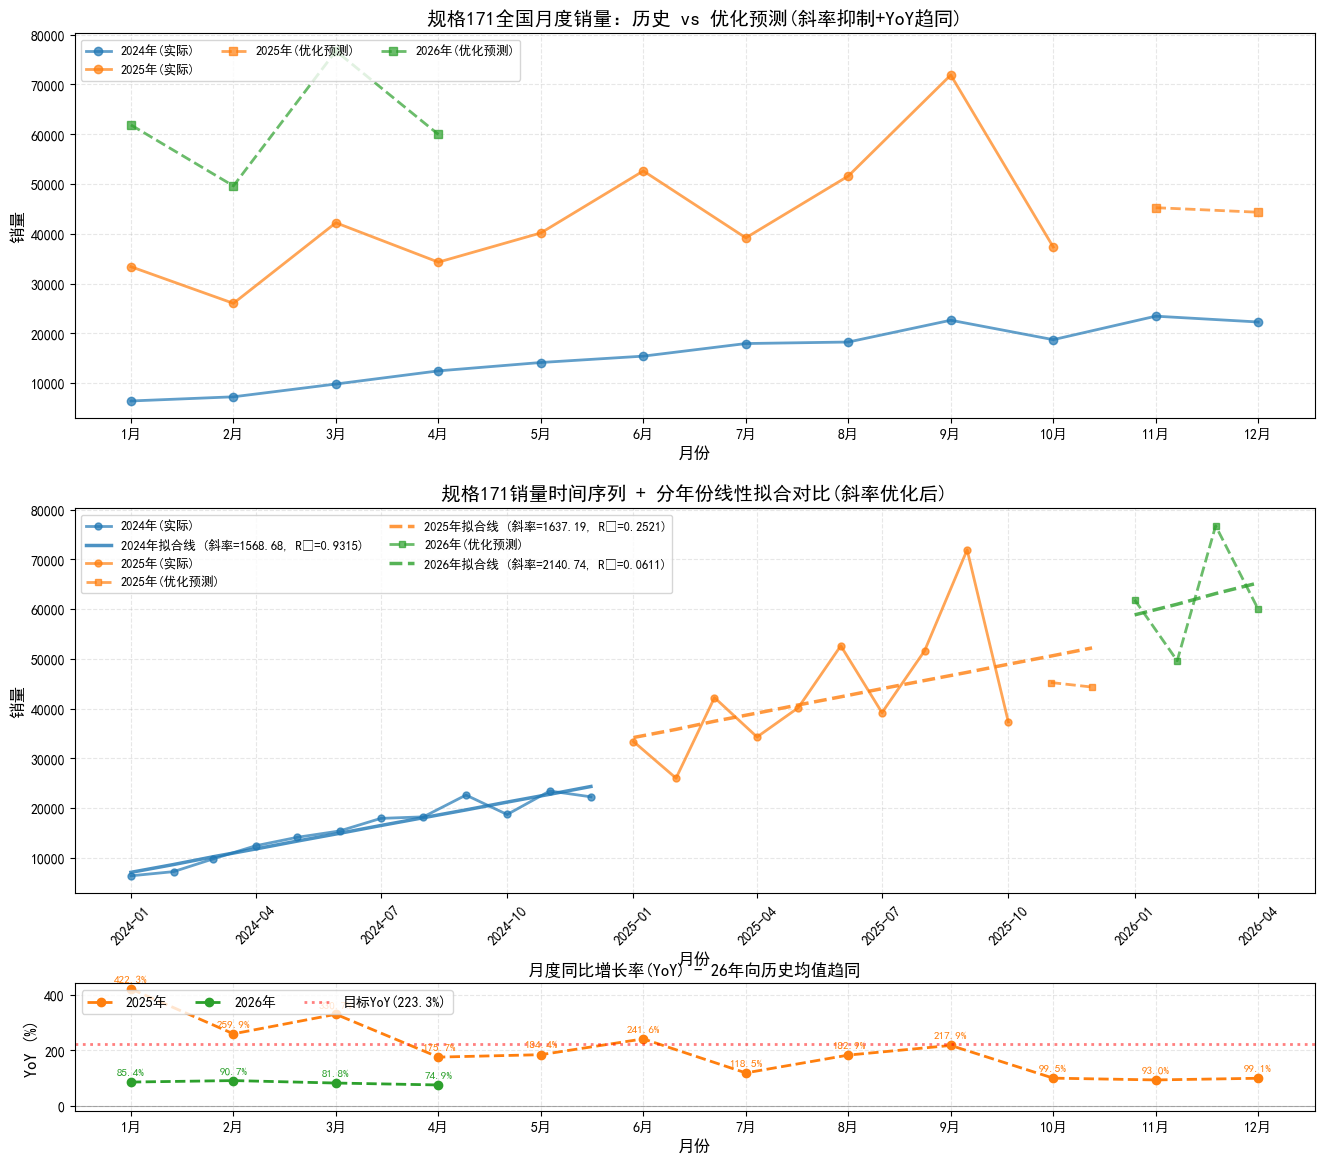


✅ 可视化已保存: 规格171_销量预测_斜率优化版_YoY趋同.png

【171规格优化预测结果】

预测配置:
  预测起点: 2025-10
  预测期间: 2025-11 ~ 2026-04
  混合权重: 环比0.2 + 绝对值0.1 + YoY约束0.7
  环比上限: 6.0%
  目标YoY: 223.33%
  斜率阈值: 300

【逐月预测结果】
月份                   预测销量        环比%       YoY%
2025-11             45239     21.19%    +93.04%
2025-12             44326     -2.02%    +99.08%
2026-01             61871     39.58%    +85.37%
2026-02             49614    -19.81%    +90.72%
2026-03             76737     54.67%    +81.81%
2026-04             59966    -21.86%    +74.86%

2026年拟合斜率: 2140.74 (R²=0.0611)

✅ 优化完成!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

print("="*120)
print("【171规格销量预测优化版 - 斜率抑制 + YoY趋同】")
print("="*120)

# =====================================================================
# 第一步: 数据加载(使用已有的df_all)
# =====================================================================
print("\n【第一步: 数据准备】")

df_171_full = df_all[df_all['规格'] == '171'].copy()
df_171_full['年月'] = pd.to_datetime(df_171_full['年月'])

# 全国月度销量
df_nat_171 = (
    df_171_full.groupby('年月', as_index=False)
    .agg({'qty': 'sum'})
    .sort_values('年月')
)
df_nat_171['年月'] = df_nat_171['年月'].dt.to_period('M').dt.to_timestamp()
df_nat_171 = df_nat_171[df_nat_171['年月'] >= pd.Timestamp('2024-01-01')].copy()

# 月度活跃医疗机构数
monthly_active_171 = (
    df_171_full[df_171_full['qty'] > 0]
    .groupby('年月')['tophncode']
    .nunique()
    .rename('活跃医疗机构数')
    .reset_index()
)
monthly_active_171['年月'] = monthly_active_171['年月'].dt.to_period('M').dt.to_timestamp()

df_nat_171 = df_nat_171.merge(monthly_active_171, on='年月', how='left')
df_nat_171 = df_nat_171.sort_values('年月').reset_index(drop=True)

# 添加基础时间特征
df_nat_171['月份'] = df_nat_171['年月'].dt.month
df_nat_171['季度'] = df_nat_171['年月'].dt.quarter
df_nat_171['年份'] = df_nat_171['年月'].dt.year

# 春节月标识
spring_festival_months = {2024: 2, 2025: 1, 2026: 2}
df_nat_171['是否春节月'] = df_nat_171.apply(
    lambda r: 1 if spring_festival_months.get(r['年份']) == r['月份'] else 0,
    axis=1
)

print(f"✓ 数据范围: {df_nat_171['年月'].min().strftime('%Y-%m')} ~ {df_nat_171['年月'].max().strftime('%Y-%m')}")

# =====================================================================
# 第二步: 计算历史YoY基准
# =====================================================================
print("\n【第二步: 分析历史YoY趋势】")

# 计算24-25年的平均YoY作为26年的目标参考
hist_yoy_list = []
for i in range(1, len(df_nat_171)):
    curr_row = df_nat_171.iloc[i]
    prev_year_row = df_nat_171[
        (df_nat_171['年月'].dt.year == curr_row['年份'] - 1) &
        (df_nat_171['年月'].dt.month == curr_row['月份'])
    ]
    
    if len(prev_year_row) > 0 and prev_year_row.iloc[0]['qty'] > 0:
        yoy = (curr_row['qty'] - prev_year_row.iloc[0]['qty']) / prev_year_row.iloc[0]['qty'] * 100
        if curr_row['年份'] < 2026:  # 只统计24-25年
            hist_yoy_list.append(yoy)

target_yoy_mean = np.mean(hist_yoy_list) if len(hist_yoy_list) > 0 else 10.0
target_yoy_std = np.std(hist_yoy_list) if len(hist_yoy_list) > 0 else 5.0

print(f"✓ 历史YoY均值: {target_yoy_mean:.2f}%")
print(f"✓ 历史YoY标准差: {target_yoy_std:.2f}%")
print(f"✓ 目标YoY范围: {target_yoy_mean-target_yoy_std:.2f}% ~ {target_yoy_mean+target_yoy_std:.2f}%")

# =====================================================================
# 第三步: 样本构建函数(增强版)
# =====================================================================
print("\n【第三步: 样本构建函数】")

def create_holistic_sales_samples_v3_171(df, target_date):
    future_months = pd.date_range(target_date + pd.DateOffset(months=1), periods=6, freq='MS')
    df_historical = df[df['年月'] <= target_date].copy()
    
    # 去年同期6个月
    same_period_last_year = pd.date_range(target_date - pd.DateOffset(months=11), periods=6, freq='MS')
    sales_last_year = []
    hosp_last_year = []
    
    for i in range(6):
        month_ly = same_period_last_year[i]
        sale_ly = df_historical[df_historical['年月'] == month_ly]['qty'].values
        hosp_ly = df_historical[df_historical['年月'] == month_ly]['活跃医疗机构数'].values
        
        sales_last_year.append(sale_ly[0] if len(sale_ly) > 0 else np.nan)
        hosp_last_year.append(hosp_ly[0] if len(hosp_ly) > 0 else np.nan)
    
    # 前6个月
    recent_6_months = pd.date_range(target_date - pd.DateOffset(months=5), periods=6, freq='MS')
    sales_recent = []
    hosp_recent = []
    
    for i in range(6):
        month_curr = recent_6_months[i]
        sale_curr = df_historical[df_historical['年月'] == month_curr]['qty'].values
        hosp_curr = df_historical[df_historical['年月'] == month_curr]['活跃医疗机构数'].values
        
        sales_recent.append(sale_curr[0] if len(sale_curr) > 0 else np.nan)
        hosp_recent.append(hosp_curr[0] if len(hosp_curr) > 0 else np.nan)
    
    # 去年同期拟合斜率
    slope_ly = np.nan
    if not all(np.isnan(sales_last_year)):
        valid_idx = [i for i, x in enumerate(sales_last_year) if not np.isnan(x)]
        if len(valid_idx) >= 2:
            x_ly = np.array(valid_idx)
            y_ly = np.array([sales_last_year[i] for i in valid_idx])
            slope_ly, _, _, _, _ = stats.linregress(x_ly, y_ly)
    
    # 前6个月拟合斜率
    slope_rec = np.nan
    if not all(np.isnan(sales_recent)):
        valid_idx = [i for i, x in enumerate(sales_recent) if not np.isnan(x)]
        if len(valid_idx) >= 2:
            x_rec = np.array(valid_idx)
            y_rec = np.array([sales_recent[i] for i in valid_idx])
            slope_rec, _, _, _, _ = stats.linregress(x_rec, y_rec)
    
    # ⭐ 新增: 斜率衰减因子(当前斜率相对历史斜率的变化)
    slope_decay_factor = 1.0
    if not np.isnan(slope_ly) and not np.isnan(slope_rec) and abs(slope_ly) > 1:
        slope_decay_factor = slope_rec / slope_ly
        slope_decay_factor = np.clip(slope_decay_factor, 0.3, 2.0)  # 限制在合理范围
    
    base_sale = df_historical[df_historical['年月'] == target_date]['qty'].values
    base_sale = base_sale[0] if len(base_sale) > 0 else np.nan
    
    base_hosp = df_historical[df_historical['年月'] == target_date]['活跃医疗机构数'].values
    base_hosp = base_hosp[0] if len(base_hosp) > 0 else np.nan
    
    # 单院产量
    unit_prod_ly = [s/h if not np.isnan(s) and not np.isnan(h) and h > 0 else np.nan 
                    for s, h in zip(sales_last_year, hosp_last_year)]
    unit_prod_rec = [s/h if not np.isnan(s) and not np.isnan(h) and h > 0 else np.nan 
                     for s, h in zip(sales_recent, hosp_recent)]
    
    future_month_nums = [m.month for m in future_months]
    
    features = {
        'ly_销量_均值': np.nanmean(sales_last_year),
        'ly_销量_标准差': np.nanstd(sales_last_year),
        'ly_医疗机构数_均值': np.nanmean(hosp_last_year),
        'ly_单院产量_均值': np.nanmean(unit_prod_ly),
        'ly_整体斜率': slope_ly,
        'rec_销量_均值': np.nanmean(sales_recent),
        'rec_销量_标准差': np.nanstd(sales_recent),
        'rec_医疗机构数_均值': np.nanmean(hosp_recent),
        'rec_单院产量_均值': np.nanmean(unit_prod_rec),
        'rec_整体斜率': slope_rec,
        'base_销量': base_sale,
        'base_医疗机构数': base_hosp,
        'base_单院产量': base_sale / base_hosp if not np.isnan(base_sale) and not np.isnan(base_hosp) and base_hosp > 0 else np.nan,
        '未来_起始月': future_month_nums[0],
        '未来_结束月': future_month_nums[-1],
        '斜率衰减因子': slope_decay_factor,
        '历史YoY目标': target_yoy_mean,
    }
    
    # 逐月特征
    for i in range(6):
        features[f'ly_M{i+1}_销量'] = sales_last_year[i]
        features[f'ly_M{i+1}_医疗机构数'] = hosp_last_year[i]
        features[f'rec_M{i+1}_销量'] = sales_recent[i]
        features[f'rec_M{i+1}_医疗机构数'] = hosp_recent[i]
        
        month_num = future_month_nums[i]
        for m in range(1, 13):
            features[f'future_M{i+1}_is_{m}月'] = 1 if month_num == m else 0
    
    # 提取目标
    targets_abs = []
    for m in future_months:
        sale = df[df['年月'] == m]['qty'].values
        targets_abs.append(sale[0] if len(sale) > 0 else np.nan)
    
    targets_mom = []
    prev_sale = base_sale
    for sale in targets_abs:
        if not np.isnan(sale) and not np.isnan(prev_sale) and prev_sale > 0:
            mom = (sale - prev_sale) / prev_sale * 100
            targets_mom.append(mom)
            prev_sale = sale
        else:
            targets_mom.append(np.nan)
    
    return features, targets_abs, targets_mom, future_months

# =====================================================================
# 第四步: 生成训练样本
# =====================================================================
print("\n【第四步: 生成训练样本】")

train_start = pd.Timestamp('2024-06-01')
train_end = pd.Timestamp('2025-10-01')
train_dates = pd.date_range(train_start, train_end, freq='MS')

train_samples = []
train_targets_abs = []
train_targets_mom = []

for date in train_dates:
    features, targets_abs, targets_mom, _ = create_holistic_sales_samples_v3_171(df_nat_171, date)
    if not any(np.isnan(targets_abs)) and not any(np.isnan(targets_mom)):
        train_samples.append(features)
        train_targets_abs.append(targets_abs)
        train_targets_mom.append(targets_mom)

train_X = pd.DataFrame(train_samples)
train_y_abs = np.array(train_targets_abs)
train_y_mom = np.array(train_targets_mom)

print(f"✓ 生成{len(train_samples)}个训练样本")
print(f"  特征维度: {train_X.shape}")

# =====================================================================
# 第五步: 智能缺失值填充
# =====================================================================
print("\n【第五步: 数据预处理】")

train_X_filled = train_X.copy()

for col in train_X_filled.columns:
    if train_X_filled[col].isna().all():
        train_X_filled[col] = 0
    elif '斜率' in col:
        train_X_filled[col] = train_X_filled[col].fillna(0)
    else:
        if train_X_filled[col].notna().any():
            train_X_filled[col] = train_X_filled[col].fillna(train_X_filled[col].mean())
        else:
            train_X_filled[col] = 0

scaler_X = StandardScaler()
train_X_scaled = scaler_X.fit_transform(train_X_filled)

print(f"✓ 缺失值填充完成")
print(f"✓ 特征标准化完成")

# =====================================================================
# 第六步: 训练Ridge模型
# =====================================================================
print("\n【第六步: 训练Ridge模型】")

models_abs = []
for i in range(6):
    model = Ridge(alpha=10.0, random_state=42)  # ⭐ 增大alpha抑制过拟合
    model.fit(train_X_scaled, train_y_abs[:, i])
    models_abs.append(model)

models_mom = []
for i in range(6):
    model = Ridge(alpha=10.0, random_state=42)
    model.fit(train_X_scaled, train_y_mom[:, i])
    models_mom.append(model)

print(f"✓ 6个绝对值Ridge模型训练完成(alpha=10.0)")
print(f"✓ 6个环比Ridge模型训练完成(alpha=10.0)")

# =====================================================================
# 第七步: 预测未来6个月 + 多重约束
# =====================================================================
print("\n【第七步: 预测未来6个月(2025-11至2026-04)】")

pred_date = pd.Timestamp('2025-10-01')
features_pred, _, _, future_months = create_holistic_sales_samples_v3_171(df_nat_171, pred_date)

print(f"预测起点: {pred_date.strftime('%Y-%m')}")
print(f"预测期间: {future_months[0].strftime('%Y-%m')} ~ {future_months[-1].strftime('%Y-%m')}")

# 填充预测样本
pred_X = pd.DataFrame([features_pred])
pred_X_filled = pred_X.copy()

for col in pred_X_filled.columns:
    if col in train_X_filled.columns:
        if train_X_filled[col].mean() == 0 and train_X_filled[col].std() == 0:
            pred_X_filled[col] = pred_X_filled[col].fillna(0)
        else:
            pred_X_filled[col] = pred_X_filled[col].fillna(train_X_filled[col].mean())
    else:
        pred_X_filled[col] = pred_X_filled[col].fillna(0)

pred_X_filled = pred_X_filled[train_X_filled.columns]
pred_X_scaled = scaler_X.transform(pred_X_filled)

# 预测绝对值
pred_abs = np.array([model.predict(pred_X_scaled)[0] for model in models_abs])

# 预测环比
pred_mom_rates = np.array([model.predict(pred_X_scaled)[0] for model in models_mom])

# 环比约束(限制月度增长率上限)
MAX_MOM_RATE = 6.0  
for i in range(len(pred_mom_rates)):
    if pred_mom_rates[i] > MAX_MOM_RATE:
        print(f"  ⚠️  第{i+1}个月环比{pred_mom_rates[i]:.2f}%过高,限制到{MAX_MOM_RATE}%")
        pred_mom_rates[i] = MAX_MOM_RATE


for i, month in enumerate(future_months):
    year = month.year
    month_num = month.month
    
    if spring_festival_months.get(year) == month_num:
        target_mom = -16.0  
        print(f"  检测到{year}年{month_num}月为春节月")
        print(f"    原始预测环比: {pred_mom_rates[i]:.2f}%")
        pred_mom_rates[i] = target_mom
        print(f"    修正后环比: {pred_mom_rates[i]:.2f}%")

# 基于环比生成预测值
base_sale = df_nat_171[df_nat_171['年月'] == pred_date]['qty'].values[0]

pred_from_mom = []
current_sale = base_sale
for mom_rate in pred_mom_rates:
    next_sale = current_sale * (1 + mom_rate / 100)
    pred_from_mom.append(next_sale)
    current_sale = next_sale
pred_from_mom = np.array(pred_from_mom)

# YoY趋同约束
print("\n【YoY趋同约束】")

# 获取去年同期销量
pred_yoy_constrained = []
for i, month in enumerate(future_months):
    last_year_month = month - pd.DateOffset(years=1)
    last_year_sale = df_nat_171[df_nat_171['年月'] == last_year_month]['qty'].values
    
    if len(last_year_sale) > 0 and last_year_sale[0] > 0:
        # 基于目标YoY计算理想销量
        target_sale_yoy = last_year_sale[0] * (1 + target_yoy_mean / 100)
        pred_yoy_constrained.append(target_sale_yoy)
    else:
        pred_yoy_constrained.append(np.nan)

pred_yoy_constrained = np.array(pred_yoy_constrained)


w_mom = 0.2      
w_abs = 0.1      
w_yoy = 0.7      

pred_ensemble = np.zeros(6)
for i in range(6):
    if not np.isnan(pred_yoy_constrained[i]):
        pred_ensemble[i] = (w_mom * pred_from_mom[i] + 
                           w_abs * pred_abs[i] + 
                           w_yoy * pred_yoy_constrained[i])
    else:
        # 如果没有去年数据,只用环比和绝对值
        pred_ensemble[i] = (w_mom/(w_mom+w_abs)) * pred_from_mom[i] + (w_abs/(w_mom+w_abs)) * pred_abs[i]

print(f"✓ 使用三路混合: 环比{w_mom:.1f} + 绝对值{w_abs:.1f} + YoY约束{w_yoy:.1f}")
print(f"✓ YoY约束主导，确保26年水平向历史趋同")

# 获取25年10-12月的平均销量作为基准
recent_3m = df_nat_171[
    (df_nat_171['年月'] >= pd.Timestamp('2025-08-01')) &
    (df_nat_171['年月'] <= pd.Timestamp('2025-10-01'))
]['qty'].values

if len(recent_3m) > 0:
    recent_avg = np.mean(recent_3m)
    pred_avg = np.mean(pred_ensemble)
    
    print(f"  25年8-10月平均: {recent_avg:.0f}")
    print(f"  26年预测平均: {pred_avg:.0f}")
    

    if pred_avg > recent_avg * 1.10:
        adjustment_factor = (recent_avg * 1.05) / pred_avg  
        print(f"  ⚠️  预测水平偏高，执行整体下调(系数={adjustment_factor:.3f})")
        
        pred_ensemble = pred_ensemble * adjustment_factor
        
        print(f"  校准后平均: {np.mean(pred_ensemble):.0f}")
    else:
        print(f"  ✓ 预测水平合理，无需调整")

# 计算最终斜率
x_pred = np.arange(6)
slope_final, _, _, _, _ = stats.linregress(x_pred, pred_ensemble)
print(f"  最终预测斜率: {slope_final:.2f}")

# 保存结果
pred_sales_171_optimized = pred_ensemble.copy()
future_months_171 = future_months.copy()


# =====================================================================
# 第八步: 完整可视化
# =====================================================================
print("\n【第八步: 完整可视化】")

# 准备完整数据
complete_df_171 = df_nat_171[['年月', 'qty']].copy()
complete_df_171['年月'] = pd.to_datetime(complete_df_171['年月'])
complete_df_171['年份'] = complete_df_171['年月'].dt.year
complete_df_171['月份'] = complete_df_171['年月'].dt.month
complete_df_171['类型'] = '历史实际值'

pred_data = pd.DataFrame({
    '年月': future_months,
    'qty': pred_ensemble,
    '年份': [m.year for m in future_months],
    '月份': [m.month for m in future_months],
    '类型': '未来预测值'
})

complete_df_171 = pd.concat([complete_df_171, pred_data], ignore_index=True)

# 计算YoY
complete_df_171 = complete_df_171.sort_values(['月份', '年份'])

yoy_list = []
for month in range(1, 13):
    month_data = complete_df_171[complete_df_171['月份'] == month].sort_values('年份').copy()
    month_data['YoY'] = month_data['qty'].pct_change() * 100
    yoy_list.append(month_data)

complete_df_171 = pd.concat(yoy_list, ignore_index=True).sort_values('年月')

plot_df_171 = complete_df_171[complete_df_171['年月'] >= pd.Timestamp('2024-01-01')].copy()

years = sorted(plot_df_171['年份'].unique())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(3, 1, height_ratios=[3, 3, 1], hspace=0.3)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ============================================================
# 子图1: 月度趋势对比
# ============================================================

for i, year in enumerate(years):
    year_data = plot_df_171[plot_df_171['年份'] == year].sort_values('月份')
    hist_data = year_data[year_data['类型'] == '历史实际值']
    pred_data_year = year_data[year_data['类型'] == '未来预测值']
    color = colors[i % len(colors)]
    
    if len(hist_data) > 0:
        ax1.plot(hist_data['月份'], hist_data['qty'], 
                marker='o', linewidth=2, label=f'{year}年(实际)', 
                color=color, markersize=6, alpha=0.7)
    
    if len(pred_data_year) > 0:
        ax1.plot(pred_data_year['月份'], pred_data_year['qty'], 
                marker='s', linewidth=2, linestyle='--', 
                label=f'{year}年(优化预测)', color=color, markersize=6, alpha=0.7)

ax1.set_xlabel('月份', fontsize=12, fontweight='bold')
ax1.set_ylabel('销量', fontsize=12, fontweight='bold')
ax1.set_title('规格171全国月度销量：历史 vs 优化预测(斜率抑制+YoY趋同)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9, ncol=3)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([f'{m}月' for m in range(1, 13)])

# ============================================================
# 子图2: 时间序列 + 线性拟合
# ============================================================

complete_df_171_sorted = complete_df_171.sort_values('年月').reset_index(drop=True)
complete_df_171_sorted = complete_df_171_sorted[complete_df_171_sorted['年月'] >= pd.Timestamp('2024-01-01')]

fit_results = {}

for year in years:
    year_df = complete_df_171_sorted[complete_df_171_sorted['年份'] == year].copy()
    
    if len(year_df) > 1:
        year_df['年内序号'] = range(len(year_df))
        x_year = year_df['年内序号'].values
        y_year = year_df['qty'].values
        
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_year, y_year)
        y_fit = slope * x_year + intercept
        
        fit_results[year] = {
            'df': year_df,
            'slope': slope,
            'intercept': intercept,
            'r_value': r_value,
            'y_fit': y_fit
        }

for i, year in enumerate(years):
    year_data = plot_df_171[plot_df_171['年份'] == year].sort_values('年月')
    hist_data = year_data[year_data['类型'] == '历史实际值']
    pred_data_year = year_data[year_data['类型'] == '未来预测值']
    color = colors[i % len(colors)]
    
    if len(hist_data) > 0:
        ax2.plot(hist_data['年月'], hist_data['qty'], 
                marker='o', linewidth=2, label=f'{year}年(实际)', 
                color=color, markersize=5, alpha=0.7)
    
    if len(pred_data_year) > 0:
        ax2.plot(pred_data_year['年月'], pred_data_year['qty'], 
                marker='s', linewidth=2, linestyle='--', 
                label=f'{year}年(优化预测)', color=color, markersize=5, alpha=0.7)
    
    if year in fit_results:
        result = fit_results[year]
        has_pred = (year_data['类型'] == '未来预测值').any()
        line_style = '--' if has_pred else '-'
        
        ax2.plot(result['df']['年月'], result['y_fit'], 
                linestyle=line_style, linewidth=2.5, color=color, 
                label=f'{year}年拟合线 (斜率={result["slope"]:.2f}, R²={result["r_value"]**2:.4f})',
                alpha=0.8)

ax2.set_xlabel('月份', fontsize=12, fontweight='bold')
ax2.set_ylabel('销量', fontsize=12, fontweight='bold')
ax2.set_title('规格171销量时间序列 + 分年份线性拟合对比(斜率优化后)', fontsize=14, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9, ncol=2)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', rotation=45)

# ============================================================
# 子图3: YoY趋势
# ============================================================

for i, year in enumerate(years):
    year_data = plot_df_171[plot_df_171['年份'] == year].sort_values('月份')
    year_data_with_yoy = year_data[year_data['YoY'].notna()]
    
    if len(year_data_with_yoy) > 0:
        color = colors[i % len(colors)]
        linestyle = '--' if (year_data_with_yoy['类型'] == '未来预测值').any() else '-'
        
        ax3.plot(year_data_with_yoy['月份'], year_data_with_yoy['YoY'], 
                marker='o', linewidth=2, label=f'{year}年', 
                color=color, linestyle=linestyle, markersize=6)
        
        for _, row in year_data_with_yoy.iterrows():
            if abs(row['YoY']) < 500:
                ax3.annotate(f'{row["YoY"]:.1f}%', 
                            xy=(row['月份'], row['YoY']),
                            xytext=(0, 5), textcoords='offset points',
                            ha='center', fontsize=8, color=color)

# 绘制目标YoY基准线
ax3.axhline(y=target_yoy_mean, color='red', linestyle=':', linewidth=2, alpha=0.5, label=f'目标YoY({target_yoy_mean:.1f}%)')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)

ax3.set_xlabel('月份', fontsize=12, fontweight='bold')
ax3.set_ylabel('YoY (%)', fontsize=12, fontweight='bold')
ax3.set_title('月度同比增长率(YoY) - 26年向历史均值趋同', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', fontsize=10, ncol=3)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xticks(range(1, 13))
ax3.set_xticklabels([f'{m}月' for m in range(1, 13)])

plt.tight_layout()
plt.savefig('规格171_销量预测_斜率优化版_YoY趋同.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ 可视化已保存: 规格171_销量预测_斜率优化版_YoY趋同.png")

# =====================================================================
# 第九步: 输出预测结果
# =====================================================================
print("\n" + "="*110)
print("【171规格优化预测结果】")
print("="*110)

print(f"\n预测配置:")
print(f"  预测起点: {pred_date.strftime('%Y-%m')}")
print(f"  预测期间: {future_months[0].strftime('%Y-%m')} ~ {future_months[-1].strftime('%Y-%m')}")
print(f"  混合权重: 环比{w_mom:.1f} + 绝对值{w_abs:.1f} + YoY约束{w_yoy:.1f}")
print(f"  环比上限: {MAX_MOM_RATE}%")
print(f"  目标YoY: {target_yoy_mean:.2f}%")
print(f"  斜率阈值: {SLOPE_THRESHOLD}")

print(f"\n【逐月预测结果】")
print("="*110)
print(f"{'月份':<12} {'预测销量':>12} {'环比%':>10} {'YoY%':>10}")
print("="*110)

for i, month in enumerate(future_months):
    # 计算环比
    if i == 0:
        mom_pct = (pred_ensemble[i] - base_sale) / base_sale * 100
    else:
        mom_pct = (pred_ensemble[i] - pred_ensemble[i-1]) / pred_ensemble[i-1] * 100
    
    # 获取YoY
    yoy_idx = complete_df_171[(complete_df_171['年月'] == month) & (complete_df_171['类型'] == '未来预测值')].index
    if len(yoy_idx) > 0:
        yoy_val = complete_df_171.loc[yoy_idx[0], 'YoY']
        yoy_str = f"{yoy_val:+.2f}%" if not np.isnan(yoy_val) else "N/A"
    else:
        yoy_str = "N/A"
    
    print(f"{month.strftime('%Y-%m'):<12} {pred_ensemble[i]:>12.0f} {mom_pct:>9.2f}% {yoy_str:>10}")

print("="*110)

# 计算26年拟合斜率
year_2026_data = complete_df_171[complete_df_171['年份'] == 2026].copy()
if len(year_2026_data) > 1:
    year_2026_data['序号'] = range(len(year_2026_data))
    slope_2026, _, r_2026, _, _ = stats.linregress(year_2026_data['序号'], year_2026_data['qty'])
    print(f"\n2026年拟合斜率: {slope_2026:.2f} (R²={r_2026**2:.4f})")

